# Week 6 · Day 4 — Multiclass Classification: More Than Two Categories

Yesterday we predicted between **two** categories — pass or fail, spam or not. But many real problems have **several**:
- which of **3 species** is this flower?
- which of **10 digits** is this handwriting?
- which of **5 topics** is this news article?

Today we extend logistic regression to handle **any number of categories**, and we learn the full toolkit for judging a classifier: the confusion matrix, precision, recall, and F1.

**The plan:**
1. How two-class becomes many-class (the *one-vs-rest* idea).
2. A real 3-class dataset — the famous Iris flowers.
3. The full evaluation toolkit — confusion matrix + classification report.
4. Interpreting: which classes does the model confuse, and why?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. How two categories become many

You already know how to build a classifier for **two** categories. The clever trick for handling more is to **turn one hard problem into several easy ones you already know how to solve.**

### One-vs-rest
To classify a flower into one of **3 species** (A, B, C), train **3 separate yes/no classifiers**:
- Classifier 1: *"Is it species A, or not?"*
- Classifier 2: *"Is it species B, or not?"*
- Classifier 3: *"Is it species C, or not?"*

Each is an ordinary binary logistic regression — exactly what you built yesterday. To classify a new flower, ask all three, and **pick the one that's most confident**. That's it. Multiclass is just *"do the binary thing several times and take the winner."*

This approach is called **one-vs-rest** (each class versus all the others).

### The alternative: softmax
There's a second approach called **softmax** — it's the natural generalization of the sigmoid to many classes, producing a set of probabilities that add up to 1 (e.g. "70% A, 20% B, 10% C") in one shot instead of three separate yes/no models.

You don't need its maths today. The point is: both approaches exist, and **scikit-learn handles the choice for you automatically.** You'll write the same code you already know, and it just works for 3, 10, or 100 classes.

---
## 2. A real 3-class dataset: Iris flowers

The **Iris** dataset is the "hello world" of classification — 150 flowers from 3 species (*setosa*, *versicolor*, *virginica*), each measured on 4 features (petal and sepal length and width). It's built right into scikit-learn.

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data          # the 4 measurements
y = iris.target        # the species (0, 1, 2)

print("species:", list(iris.target_names))
print("features:", list(iris.feature_names))
print("total flowers:", len(X))

species: ['setosa', 'versicolor', 'virginica']
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
total flowers: 150


In [3]:
# Put it in a DataFrame to explore it (Week 4 skills)
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in y]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Explore: are the classes balanced?
Before modelling, check how many examples of each class we have. Balanced classes (roughly equal counts) make life easier; heavily imbalanced ones cause problems we'll discuss later.

In [4]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Perfectly balanced — 50 of each. Now let's *see* the flowers. If we plot two features and colour by species, we can eyeball whether they separate cleanly.

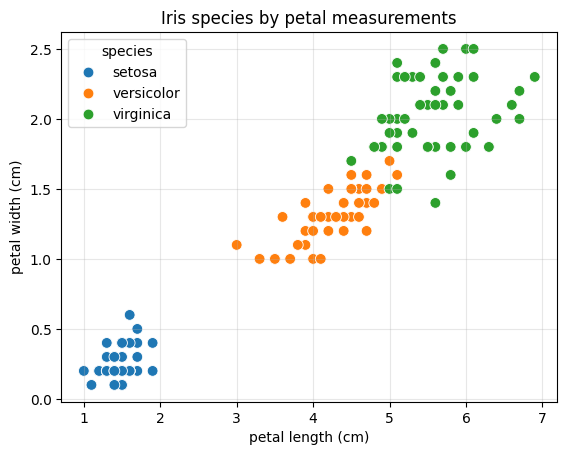

In [5]:
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",hue="species", s=60)
plt.title("Iris species by petal measurements")
plt.grid(True, alpha=0.3)
plt.show()

A crucial observation for later: **setosa** (one colour) sits completely apart — easy to identify. But **versicolor** and **virginica** overlap in the middle — they're similar flowers. Keep this in mind; the model will struggle in exactly the same place we do.

---
## 3. Train the classifier

The workflow is **identical** to yesterday's binary logistic regression — same four steps. `LogisticRegression` detects there are 3 classes and handles the multiclass part automatically.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# split, keeping the class balance in both halves (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print("model trained on", len(X_train), "flowers")

model trained on 105 flowers


In [7]:
# predict the species of the held-out test flowers
predictions = model.predict(X_test)

# it can also give the probability for each of the 3 classes
example = X_test[0].reshape(1, -1)
probs = model.predict_proba(example)[0]
print("For one test flower, the model's confidence in each species:")
for name, p in zip(iris.target_names, probs):
    print(f"  {name:12s}: {p:.1%}")
print("→ it picks the most confident:", iris.target_names[model.predict(example)[0]])

For one test flower, the model's confidence in each species:
  setosa      : 0.0%
  versicolor  : 3.2%
  virginica   : 96.8%
→ it picks the most confident: virginica


See the one-vs-rest idea in action — the model reports a confidence for *each* species and picks the highest. That's exactly "ask all three, take the winner." 

---
## 4. Evaluating a multiclass model

Yesterday we used accuracy and a 2×2 confusion matrix. With 3 classes, the tools grow — but the ideas are the same.

### Accuracy first

In [8]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, predictions)
print(f"accuracy = {acc:.1%}  (fraction of test flowers classified correctly)")

accuracy = 93.3%  (fraction of test flowers classified correctly)


93% correct — good. But accuracy is a single number that hides *which* flowers it got wrong. For that, we need the confusion matrix.

### The confusion matrix — now 3×3
With 3 classes, the confusion matrix is a **3×3 grid**. Each row is the *true* species; each column is the *predicted* species. The **diagonal** (top-left to bottom-right) is correct predictions; anything **off the diagonal** is a mistake — and it shows you *exactly which species got mistaken for which*.

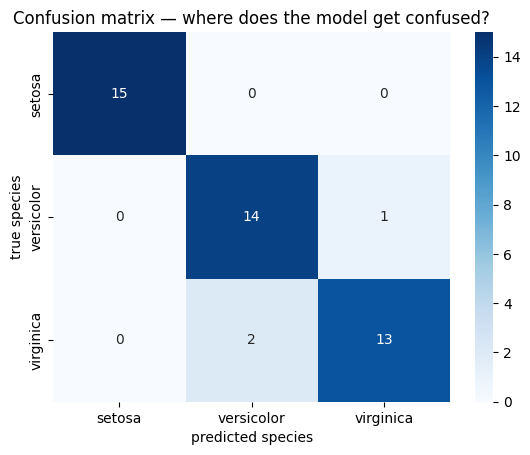

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("predicted species"); plt.ylabel("true species")
plt.title("Confusion matrix — where does the model get confused?")
plt.show()

Read the grid:
- **setosa** — a perfect row and column, no mistakes. Just as we predicted from the scatter plot: it's the one that sits apart.
- **versicolor** and **virginica** — the off-diagonal numbers are all between *these two*. The model occasionally calls a versicolor a virginica and vice versa.

The model is confused in **exactly the place we were confused** looking at the scatter plot. The confusion matrix turned our visual hunch into hard evidence.

### Precision, recall, and F1 — the full report
Accuracy is one overall number. To judge the model **per class**, we use three metrics. In plain words, for any one class (say *virginica*):

- **Precision** — *"when the model says virginica, how often is it right?"* (Of all its virginica guesses, what fraction were truly virginica?)
- **Recall** — *"of all the real virginicas, how many did it catch?"* (Did it miss any?)
- **F1 score** — a single number **balancing** precision and recall, useful when you want one figure per class.

`classification_report` prints all three for every class at once.

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



Read it row by row:
- **setosa** — 1.00 across the board. Flawless, as expected.
- **versicolor** and **virginica** — slightly below 1.0 on precision and recall, because they get mixed up with each other. Their F1 scores reflect that small imperfection.

This is far more informative than the single accuracy number. Accuracy said "93% good"; the report tells us *the model is perfect on setosa and only stumbles between the two similar species* — a precise, actionable diagnosis.

---
## 5. Why accuracy alone can lie

Here's a warning that matters enormously in real projects. Imagine a dataset where **95% of examples are one class** (e.g. 95% of emails are *not* spam). A lazy model that simply says *"not spam, always"* would be **95% accurate** — and completely useless, because it never catches a single spam.

This is why we use precision, recall, and the confusion matrix — they reveal what accuracy hides. On **imbalanced** data especially, a high accuracy can be a trap. Always look deeper than the single number.

*(Iris is balanced, so its accuracy is trustworthy — but not every dataset is so kind.)*

---
## 6. Interpreting the model

Let's directly answer the practical question: **which two species does the model most often confuse?** We can read it straight from the confusion matrix's off-diagonal entries.

In [11]:
# find the biggest off-diagonal (mistake) entries
cm = confusion_matrix(y_test, predictions)
names = iris.target_names

print("Mistakes the model made:")
for true_i in range(len(names)):
    for pred_i in range(len(names)):
        if true_i != pred_i and cm[true_i, pred_i] > 0:
            print(f"  {cm[true_i, pred_i]} × {names[true_i]} wrongly called {names[pred_i]}")

Mistakes the model made:
  1 × versicolor wrongly called virginica
  2 × virginica wrongly called versicolor


Every mistake is between **versicolor** and **virginica** — the two overlapping species. Not a single setosa was ever misclassified. The model learned the real structure of the data: two of the three flowers genuinely look alike, and that's where the errors concentrate.

### The tools generalize
Notice that everything today — confusion matrix, precision, recall, F1 — is the *same toolkit* from yesterday's binary problem, just extended from 2 classes to 3. Tomorrow's SVM, and every classifier you ever build, is judged with these exact same tools. Learn them once, use them forever.

---
## Summary

- **Multiclass classification** predicts one of several categories (3 species, 10 digits, ...).
- **One-vs-rest** turns it into several binary problems you already know: "class A or not?", "B or not?", ... then pick the most confident. **Softmax** is the alternative; scikit-learn handles the choice automatically.
- The code is **identical** to binary logistic regression — `LogisticRegression().fit()` just works for any number of classes.
- The **confusion matrix** (now N×N) shows exactly which classes get confused with which — the diagonal is correct, off-diagonal are mistakes.
- **Precision** ("when it says X, how often right?"), **recall** ("of all real X, how many caught?"), and **F1** (their balance) judge the model per class, via `classification_report`.
- **Accuracy alone can lie**, especially on imbalanced data — always look at the fuller metrics.
- On Iris, the model is perfect on *setosa* but confuses *versicolor* and *virginica* — exactly the two species that overlap, a real finding straight from the data.

Next time: **Support Vector Machines** — a different, powerful way to draw the boundary between classes, judged with these same tools.